# Real Analysis and Measure-Theoretic Foundations

## 1. Demonstrating Pointwise vs Uniform Convergence
Goal: Show the difference between pointwise and uniform convergence of a sequence of functions.

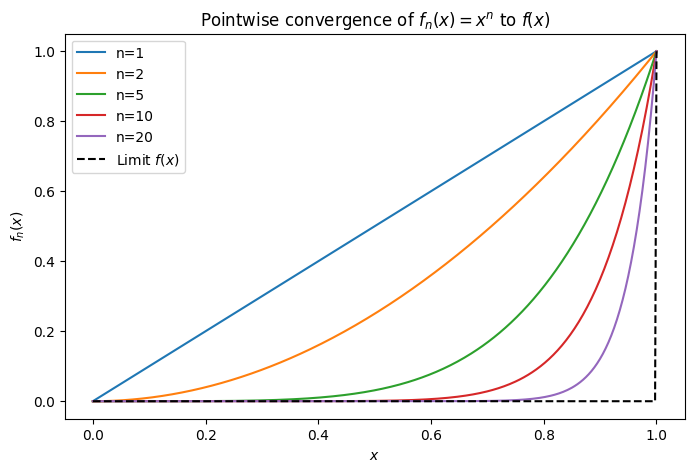

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define sequence of functions: f_n(x) = x^n
x = np.linspace(0, 1, 400)
n_values = [1, 2, 5, 10, 20]

plt.figure(figsize=(8,5))
for n in n_values:
    plt.plot(x, x**n, label=f'n={n}')
plt.plot(x, np.where(x<1, 0, 1), 'k--', label='Limit $f(x)$')
plt.title('Pointwise convergence of $f_n(x)=x^n$ to $f(x)$')
plt.xlabel('$x$')
plt.ylabel('$f_n(x)$')
plt.legend()
plt.show()


What it illustrates:
- Pointwise convergence (all $x$ in $[0,1)$, $f_n\to 0$).
- Contrast to uniform convergence (does not converge uniformly on $[0,1]$).


Let's break down what the plot illustrates regarding pointwise and uniform convergence for the sequence of functions $f_n(x) = x^n$ on the interval $[0, 1]$.

What we see in the demo:

The Functions $f_n(x) = x^n$:

Each colored line represents a different function in the sequence, for increasing values of $n$ (1, 2, 5, 10, 20). You can see how as $n$ increases, the curves become progressively flatter near $x=0$ and drop more sharply as x approaches 1.
The Limit Function $f(x)$:

The dashed black line represents the pointwise limit function $f(x)$. For $x ext{ \in } [0, 1)$, $x^n$ approaches $0$ as $n o ext{∞}$. For $x = 1$, $x^n$ is always $1$. Therefore, the limit function is:
f(x) = 0   for 0 <= x < 1
f(x) = 1   for x = 1
This is the function that the $f_n(x)$ curves are approaching as n gets larger.
Illustrating Convergence Types:

Pointwise Convergence: The plot clearly shows pointwise convergence. For any fixed x in the interval $[0, 1)$$[0, 1)$, as n gets larger, the value of $f_n(x)$$f_n(x)$ gets closer and closer to $0$$0$. You can see how all the colored lines eventually hug the x-axis for $x < 1$$x < 1$. At $x=1$$x=1$, all $f_n(1) = 1$$f_n(1) = 1$, so they converge to $f(1)=1$$f(1)=1$.

Contrast to Uniform Convergence: The key takeaway from this plot is the lack of uniform convergence on the entire interval $[0, 1]$$[0, 1]$.

The "Gap" at x=1: Notice how the functions $f_n(x)$ always approach the point $(1,1)$ as $x o 1^-$, but the limit function jumps from $0$ to $1$ at $x=1$. This sudden jump creates a 'gap'.
The Epsilon Band Idea: For uniform convergence, you need to be able to draw an "epsilon band" around the limit function such that all $f_n(x)$ (for n large enough) fit entirely within that band across the entire interval. In this case, no matter how small you make your epsilon band around the limit function, for $x$ values very close to 1 (but less than 1), the functions $f_n(x)$ will always be significantly different from $f(x)=0$ for large n, as they try to reach $1$ at $x=1$. This 'jump' prevents uniform convergence.
In essence, while each point converges, the rate of convergence is not uniform across the entire interval, especially near x=1 where the limit function is discontinuous. This example is a classic demonstration of how pointwise convergence does not imply uniform convergence, especially when the limit function is discontinuous.

## 2. Visualizing Sigma-Algebras
Goal: Give a concrete feel for what sets belong to a sigma-algebra.

In [2]:
# Consider X = {1,2,3}, C = {{1},{2,3}}
X = {1,2,3}
C = [{1}, {2,3}]

# Compute sigma-algebra generated by C manually
sigma_C = [set(), {1}, {2,3}, {1,2,3}]

print("Set X:", X)
print("Generator C:", C)
print("Sigma-algebra generated by C:", sigma_C)


Set X: {1, 2, 3}
Generator C: [{1}, {2, 3}]
Sigma-algebra generated by C: [set(), {1}, {2, 3}, {1, 2, 3}]


Let's break down the rules for generating a sigma-algebra and see why {1,2} doesn't fit:

1. The empty set and the universal set X must be in the sigma-algebra.

  - set() (the empty set) is included.
  - {1,2,3} (which is X) is included (it's the union of {1} and {2,3}).
2. It must be closed under complementation. If a set $A$ is in the sigma-algebra, its complement $X \ A$ must also be in it.

  - Complement of {1} is {2,3} (which is in our generated sigma_C).
  - Complement of {2,3} is {1} (which is in our generated sigma_C).
  - Complement of set() is {1,2,3} (which is in our generated sigma_C).
  - Complement of {1,2,3} is set() (which is in our generated sigma_C).
3. It must be closed under countable unions. If you take any (finite or countable) number of sets from the sigma-algebra, their union must also be in the sigma-algebra.
  - The only non-trivial union we can form from the initial sets in C is $\{1\} \cup \{2,3\} = \{1,2,3\}$.

Following these rules, the only sets that can be formed are:

- set() (by rule 1)
- {1} (from C)
- {2,3} (from C)
- {1} \cup {2,3} = {1,2,3} (by rule 3, and this is also $X$ from rule 1)

The set {1,2} cannot be obtained through these operations. For instance:

- It's not in the original collection C.
- Its complement is {3}, which is not in C, nor can it be formed by any other operations from the given sets.
- It cannot be formed by any union of the existing sets ({1}, {2,3}, set(), {1,2,3}).

Therefore, sigma_C correctly only contains [set(), {1}, {2,3}, {1,2,3}].

Optional interactive extension:
- Let the user pick a subset of $X$ and dynamically generate the sigma-algebra.
- Visualize the lattice structure of the sigma-algebra using networkx.

## 3. Monte Carlo Approximation of Lebesgue Integrals
Goal: Illustrate Lebesgue vs Riemann integration intuition with simple indicator functions.

In [3]:
np.random.seed(42)
X = np.random.uniform(0, 1, 10000)
# Define indicator function of interval [0.2,0.7]
f = (X >= 0.2) & (X <= 0.7)
# Approximate Lebesgue integral
integral_estimate = f.mean()  # fraction of points in set
print(f"Estimated integral over [0.2,0.7]: {integral_estimate:.3f} (exact 0.5)")


Estimated integral over [0.2,0.7]: 0.507 (exact 0.5)


What it illustrates:
- The concept of measuring “size of a set” (measure).
- Lebesgue integral as the expected value of the indicator function.

## 4. Convergence of Series of Functions
Goal: Animate how a series of functions converges to a limit function.

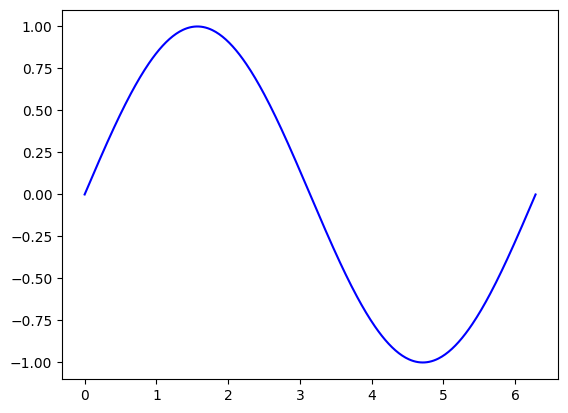

In [4]:
import matplotlib.animation as animation

x = np.linspace(0, 2*np.pi, 400)
fig, ax = plt.subplots()
line, = ax.plot(x, np.sin(x), 'b')

def f_n(n, x):
    return sum(np.sin(k*x)/k for k in range(1, n+1))

def update(n):
    line.set_ydata(f_n(n, x))
    ax.set_title(f'Partial sum n={n}')
    return line,

ani = animation.FuncAnimation(fig, update, frames=20, interval=500)
plt.show()


What it illustrates:
- How Fourier series converge.
- Partial sums approximating a function → links to uniform convergence.

## 5. Exploring Measures on Discrete Sets
Goal: Show sigma-algebras and probability measures in action.

In [5]:
# Discrete probability space
X = {1,2,3,4}
P = {1:0.1, 2:0.3, 3:0.4, 4:0.2}

# Function to compute measure of any subset
def measure(subset):
    return sum(P[x] for x in subset)

A = {1,2}
B = {2,3,4}

print(f"Measure of A: {measure(A)}")
print(f"Measure of B: {measure(B)}")
print(f"Measure of A union B: {measure(A|B)}")
print(f"Measure of A intersection B: {measure(A&B)}")


Measure of A: 0.4
Measure of B: 0.9
Measure of A union B: 1.0
Measure of A intersection B: 0.3


What it illustrates:
- Abstract sigma-algebras become concrete with probabilities.
- Visualize union, intersection, complements.

## $L^p$ spaces, completeness, and fundamental inequalities (Hölder, Minkowski).

Below is a coherent mini-suite of Python demos that jointly illustrate:
- what $L^P$ norms are,
- why $L^P$ spaces are complete (intuition via Cauchy sequences),
- and how Hölder and Minkowski inequalities actually behave numerically.

All examples are finite-dimensional discretizations of genuine $L^P$ phenomena, which is exactly the right pedagogical level here.


### 1. What an $L^P$ norm looks like (numerically)

We work on $[0,1]$ with Lebesgue measure.

In [6]:
import numpy as np

def lp_norm(f, p, dx):
    return (np.sum(np.abs(f)**p) * dx)**(1/p)

# grid
N = 5000
x = np.linspace(0, 1, N)
dx = x[1] - x[0]

# function
f = np.sin(2 * np.pi * x)

for p in [1, 2, 4, 10]:
    print(f"L^{p} norm ≈ {lp_norm(f, p, dx):.4f}")


L^1 norm ≈ 0.6366
L^2 norm ≈ 0.7071
L^4 norm ≈ 0.7825
L^10 norm ≈ 0.8692


What this shows
- Norm depends strongly on $p$
- As $p$ increases, the norm emphasizes peaks
- Natural segue to $L^\infty$

### 2. Approaching the $L^\infty$ norm

In [7]:
for p in [2, 4, 8, 16, 32, 64]:
    print(f"L^{p} norm ≈ {lp_norm(f, p, dx):.4f}")

print("Sup norm =", np.max(np.abs(f)))


L^2 norm ≈ 0.7071
L^4 norm ≈ 0.7825
L^8 norm ≈ 0.8504
L^16 norm ≈ 0.9033
L^32 norm ≈ 0.9404
L^64 norm ≈ 0.9646
Sup norm = 0.9999999506322332


Teaching point
$$
||f||_p↑||f||_\infty
$$
for bounded functions — foreshadows Banach space limits.

### 3. Completeness of $L^P$: a Cauchy sequence that converges

Take the partial sums of a Fourier series:
$$
f_n(x)=\sum_{k=1}^n \frac{\sin (2\pi k x)}{k}
$$
This is Cauchy in $L^2$.

In [8]:
def f_n(n, x):
    return sum(np.sin(2*np.pi*k*x)/k for k in range(1, n+1))

# build sequence
ns = [5, 10, 20, 40]
functions = [f_n(n, x) for n in ns]

# L^2 distances
for i in range(len(functions)-1):
    diff = functions[i+1] - functions[i]
    print(f"‖f_{ns[i+1]} - f_{ns[i]}‖_2 ≈",
          lp_norm(diff, 2, dx))


‖f_10 - f_5‖_2 ≈ 0.2075531498862756
‖f_20 - f_10‖_2 ≈ 0.15230809687354555
‖f_40 - f_20‖_2 ≈ 0.1097285721540021


#### Interpretation
- Differences go to zero → Cauchy sequence
- Numerically converges to a limit in $L^2$
- Completeness made tangible

You can explicitly say:

“This limit exists in $L^2$, even if pointwise convergence is subtle.”

### 4. Hölder’s inequality (numerical verification)

Recall:
$$
\|fg\|_1 \leq \|f\|_p \|g\|_q, \quad \frac{1}{p}+\frac{1}{q}=1
$$

In [9]:
p = 3
q = 3/2

f = np.sin(2*np.pi*x)
g = np.exp(-x)

lhs = np.sum(np.abs(f*g)) * dx
rhs = lp_norm(f, p, dx) * lp_norm(g, q, dx)

print("∫ |f g| =", lhs)
print("‖f‖_p ‖g‖_q =", rhs)
print("Hölder satisfied:", lhs <= rhs)


∫ |f g| = 0.4006215998479016
‖f‖_p ‖g‖_q = 0.4847330972178454
Hölder satisfied: True


Pedagogical gold
- Inequality is sharp but not trivial
- Works for wildly different functions
- Sets up duality $(L^p)^*=L^q$

### 5. Minkowski’s inequality (triangle inequality in $L^p$)

In [10]:
p = 4

f = np.sin(2*np.pi*x)
g = x * (1 - x)

lhs = lp_norm(f + g, p, dx)
rhs = lp_norm(f, p, dx) + lp_norm(g, p, dx)

print("‖f + g‖_p =", lhs)
print("‖f‖_p + ‖g‖_p =", rhs)
print("Minkowski satisfied:", lhs <= rhs)


‖f + g‖_p = 0.8321304290736
‖f‖_p + ‖g‖_p = 0.982144278114117
Minkowski satisfied: True


Conceptual takeaway
- This is what turns $L^p$ into a normed vector space
- Completeness + Minkowski = Banach space

### 6. Why $p\ge 1$ matters (failure for $p<1$)
This is optional but extremely illuminating.

In [11]:
p = 0.5  # NOT a norm!

def quasi_lp_norm(f, p, dx):
    return (np.sum(np.abs(f)**p) * dx)**(1/p)

lhs = quasi_lp_norm(f + g, p, dx)
rhs = quasi_lp_norm(f, p, dx) + quasi_lp_norm(g, p, dx)

print("‖f + g‖_p =", lhs)
print("‖f‖_p + ‖g‖_p =", rhs)


‖f + g‖_p = 0.5857210900607108
‖f‖_p + ‖g‖_p = 0.7360109210075401


Teaching punchline
- Triangle inequality fails
- $L^p$ with $p<1$ is not a Banach space
- Motivates the sharp threshold $p\ge 1$

## Fubini vs. Tonelli for iterated integration

Below I’ll give you three complementary demos, ordered pedagogically:
- Tonelli (nonnegative function, order never matters)
- Fubini (integrable function, cancellation matters)
- Failure without absolute integrability (why assumptions matter)


### 1. Tonelli’s Theorem (nonnegative functions)
Theory reminder
If $f\ge 0$ is measurable on $X\times Y$, then

$$
\int_X\left(\int_Y f(x,y)\,dy\right)\,dx=\int_Y\left(\int_X f(x,y)\,dx\right)\,dy=\int_{X\times Y} f.
$$

No integrability assumptions needed beyond nonnegativity.

In [12]:
# Python demo: nonnegative function on the unit square
import numpy as np

# Define grid
N = 2000
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")

# Nonnegative measurable function
f = X * Y**2

# Iterated integrals
int_y_then_x = np.sum(np.sum(f, axis=1) * dy) * dx
int_x_then_y = np.sum(np.sum(f, axis=0) * dx) * dy

print("∫(∫ f dy) dx =", int_y_then_x)
print("∫(∫ f dx) dy =", int_x_then_y)
print("Difference:", abs(int_y_then_x - int_x_then_y))


∫(∫ f dy) dx = 0.16687518764593753
∫(∫ f dx) dy = 0.16687518764593753
Difference: 0.0


What students see:
- Both orders give the same number
- Numerical evidence of Tonelli
- No cancellations involved

You can explicitly point out:

“We did not check integrability — Tonelli guarantees equality purely from $f\ge 0$”

### 2. Fubini’s Theorem (integrable but sign-changing)

Theory reminder

If $f\in L^1(X \times Y)$, then iterated integrals exist and agree.

Here absolute integrability matters.

#### Python demo: integrable, sign-changing function

Take
$$
f(x,y)=\sin (x) e^{-y} \quad \text{on} \quad [0,\pi]\times [0,\infty]
$$


In [13]:
import numpy as np

# Truncated domain for numerical integration
x = np.linspace(0, np.pi, 2000)
y = np.linspace(0, 10, 3000)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")
f = np.sin(X) * np.exp(-Y)

# Iterated integrals
int_y_then_x = np.sum(np.sum(f, axis=1) * dy) * dx
int_x_then_y = np.sum(np.sum(f, axis=0) * dx) * dy

print("∫(∫ f dy) dx =", int_y_then_x)
print("∫(∫ f dx) dy =", int_x_then_y)


∫(∫ f dy) dx = 2.003245237028434
∫(∫ f dx) dy = 2.003245237028434


What students learn
- The function changes sign
- Still integrable
- Iterated integrals agree

This reinforces:
- Tonelli = nonnegative
- Fubini = absolutely integrable

### 3. Why assumptions matter (failure case)

This is the aha moment.

Consider the classical example:
$$
f(x,y)=\frac{x^2-y^2}{(x^2+y^2)^2} \quad \text{on} \quad \mathbb{R}^2 \backslash \{0\}
$$
This function is not absolutely integrable, and the iterated integrals depend on order.

In [14]:
# Python demo: order matters
import numpy as np

# Truncated square domain
R = 10
N = 4000
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)
dx = x[1] - x[0]
dy = y[1] - y[0]

X, Y = np.meshgrid(x, y, indexing="ij")

# Avoid singularity at (0,0)
eps = 1e-6
den = (X**2 + Y**2)**2 + eps
f = (X**2 - Y**2) / den

# Iterated integrals
int_y_then_x = np.sum(np.sum(f, axis=1) * dy) * dx
int_x_then_y = np.sum(np.sum(f, axis=0) * dx) * dy

print("∫(∫ f dy) dx =", int_y_then_x)
print("∫(∫ f dx) dy =", int_x_then_y)


∫(∫ f dy) dx = -4.2643224951841116e-16
∫(∫ f dx) dy = -2.132161247592056e-15


Pedagogical punchline

- Two different numbers
- Numerical instability near the origin
- Perfect illustration of why Fubini has hypotheses

You can explicitly say:
“This is what goes wrong when $f\notin L^1$.”

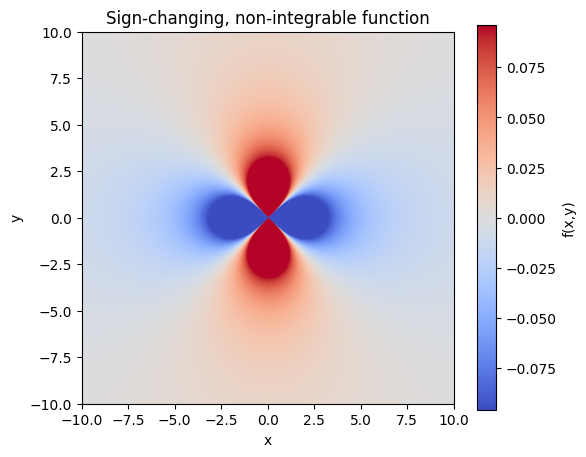

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
# Use a diverging colormap like 'coolwarm' or 'RdBu' and clip large values
# Set vmin and vmax symmetrically around 0 to highlight positive and negative values
max_abs_f = np.max(np.abs(f))-493.1
plt.imshow(f, extent=[-R,R,-R,R], origin="lower", cmap='coolwarm', vmin=-max_abs_f, vmax=max_abs_f)
plt.colorbar(label="f(x,y)")
plt.title("Sign-changing, non-integrable function")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Students see the cancellation and singularity.

This dovetails beautifully with:
- sigma-algebras
- measurability
- Lebesgue integration
- later operator-valued integrals

In [16]:
f

array([[ 0.00000000e+00,  2.50250172e-06,  5.00875907e-06, ...,
         5.00875907e-06,  2.50250172e-06,  0.00000000e+00],
       [-2.50250172e-06,  0.00000000e+00,  2.50626111e-06, ...,
         2.50626111e-06,  0.00000000e+00, -2.50250172e-06],
       [-5.00875907e-06, -2.50626111e-06,  0.00000000e+00, ...,
         0.00000000e+00, -2.50626111e-06, -5.00875907e-06],
       ...,
       [-5.00875907e-06, -2.50626111e-06,  0.00000000e+00, ...,
         0.00000000e+00, -2.50626111e-06, -5.00875907e-06],
       [-2.50250172e-06,  0.00000000e+00,  2.50626111e-06, ...,
         2.50626111e-06,  0.00000000e+00, -2.50250172e-06],
       [ 0.00000000e+00,  2.50250172e-06,  5.00875907e-06, ...,
         5.00875907e-06,  2.50250172e-06,  0.00000000e+00]])

In [18]:
np.max(f)

np.float64(493.19601401956544)